In [1]:
import networkx as nx, numpy as np, matplotlib.pyplot as plt
G = nx.read_edgelist("networks/inf-euroroad/inf-euroroad.edges",
                     create_using=nx.Graph(), nodetype=int, comments="%")


##  Import the data, draw their histogram.

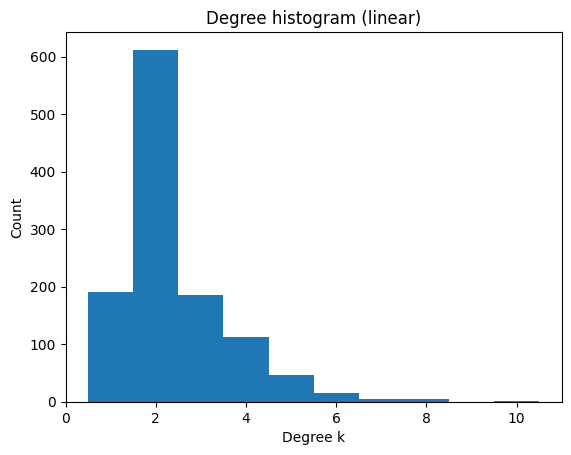

In [2]:
deg = np.array([d for _, d in G.degree()], dtype=int)

edges = np.arange(deg.min(), deg.max() + 2) - 0.5
counts, edges = np.histogram(deg, bins=edges, density=False)
centers = 0.5 * (edges[1:] + edges[:-1])

plt.figure()
plt.bar(centers, counts, width=1.0, edgecolor="none")
plt.xlabel("Degree k")
plt.ylabel("Count")
plt.title("Degree histogram (linear)")
plt.show()


##  Correct the scale of the plot’s axes to double logarithmic.

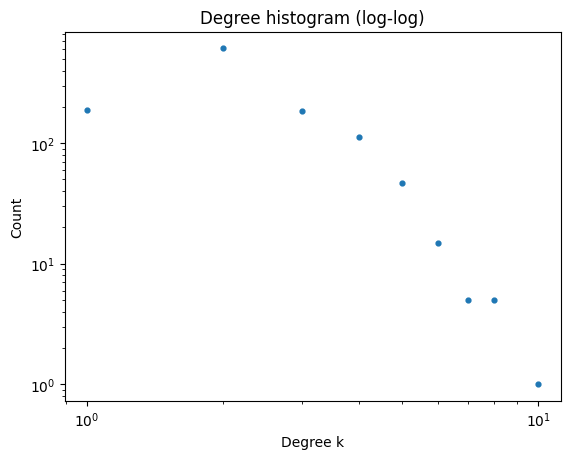

In [3]:
plt.figure()
plt.scatter(centers, counts, s=12)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Degree k")
plt.ylabel("Count")
plt.title("Degree histogram (log-log)")
plt.show()


##  Apply logarithmic binning as well.

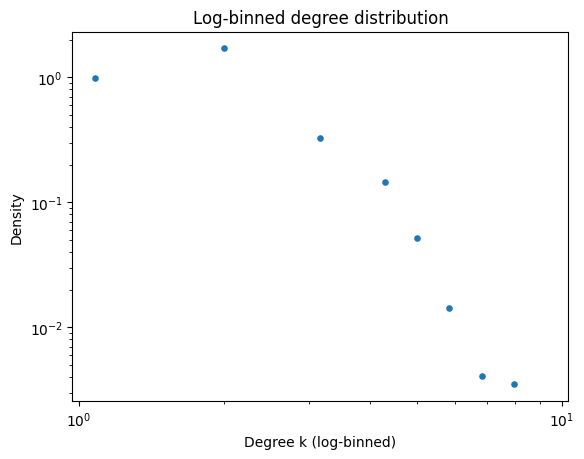

In [4]:
# remove zeros
mask = (centers > 0) & (counts > 0)
x = centers[mask]; y = counts[mask]

xmin, xmax = x.min(), x.max()
nbins = 15
bins = np.logspace(np.log10(xmin), np.log10(xmax), nbins + 1)

binned = np.zeros(nbins)
for i in range(nbins):
    m = (x >= bins[i]) & (x < bins[i+1])
    binned[i] = np.sum(y[m])

widths = np.diff(bins)
density = binned / (np.sum(binned) * widths)
xb = np.sqrt(bins[:-1] * bins[1:])

plt.figure()
plt.scatter(xb, density, s=14)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Degree k (log-binned)")
plt.ylabel("Density")
plt.title("Log-binned degree distribution")
plt.show()


##  Compute and draw the survival function. https://www.geeksforgeeks.org/artificial-intelligence/survival-function/

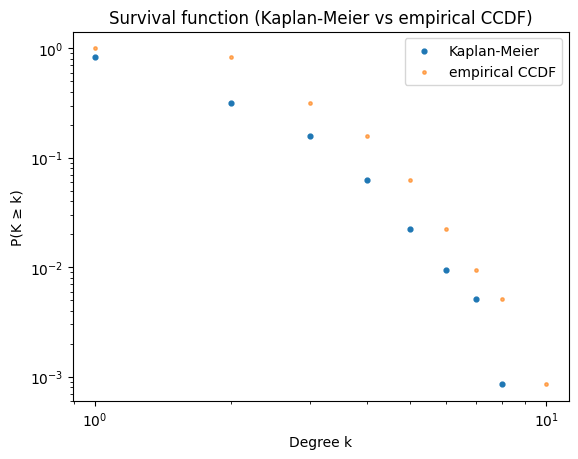

In [5]:
v = np.sort(deg)
uniq, cnt = np.unique(v, return_counts=True)

n_at_risk = np.cumsum(cnt[::-1])[::-1].astype(float)

S_km = np.ones_like(cnt, dtype=float)
prod = 1.0
for i, d_i in enumerate(cnt):
    n_i = n_at_risk[i]
    if n_i > 0:
        prod *= (1.0 - float(d_i) / n_i)
    S_km[i] = prod

tail = n_at_risk.copy()
S_emp = tail / tail[0]

plt.figure()
plt.scatter(uniq, S_km, s=12, label="Kaplan-Meier")
plt.scatter(uniq, S_emp, s=6, alpha=0.6, label="empirical CCDF")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Degree k")
plt.ylabel("P(K ≥ k)")
plt.title("Survival function (Kaplan-Meier vs empirical CCDF)")
plt.legend()
plt.show()


## Which chart is the most readable? Which is most robust for the noise?

## Log-binned histograms reduce noise in the tail and make the heavy-tailed region clearer.
## The CCDF is the most robust since it avoids bin choices and smooths fluctuations.
## The plain log-log histogram is the noisiest for large k.

## Use the linear regression to the previous plot to determine the parameter estimator.

In [7]:
xmin_fit = 2

# PMF from histogram (width = 1)
pmf = counts / np.sum(counts)

# slope on log-log plot of p(k)
mask = (centers >= xmin_fit) & (pmf > 0)
X = np.log10(centers[mask])
Y = np.log10(pmf[mask])
A = np.vstack([X, np.ones_like(X)]).T
slope_pmf, intercept_pmf = np.linalg.lstsq(A, Y, rcond=None)[0]
alpha_from_pmf = -slope_pmf

# Use the computed survival (choose empirical CCDF or Kaplan–Meier)
S = S_emp  # or S = S_km

# slope on CCDF plot (only positive S and degrees >= xmin_fit)
mask2 = (uniq >= xmin_fit) & (S > 0)
if np.sum(mask2) < 2:
    alpha_from_ccdf = np.nan
else:
    X2 = np.log10(uniq[mask2]).astype(float)
    Y2 = np.log10(S[mask2]).astype(float)
    A2 = np.vstack([X2, np.ones_like(X2)]).T
    slope_ccdf, intercept_ccdf = np.linalg.lstsq(A2, Y2, rcond=None)[0]
    alpha_from_ccdf = 1 - slope_ccdf

print("alfa (from PMF) ≈", alpha_from_pmf)
print("alfa (from CCDF) ≈", alpha_from_ccdf)


alfa (from PMF) ≈ 3.961827684548651
alfa (from CCDF) ≈ 5.193818284197997


## Compute (formula and value for our data) MLE estimator for with a known xmin assuming following distribution

In [8]:
xmin_known = 2
v_tail = deg[deg >= xmin_known]
n = len(v_tail)
alpha_mle = 1 + n / np.sum(np.log(v_tail / xmin_known))
alpha_mle
print("alfa (MLE) ≈", alpha_mle)

alfa (MLE) ≈ 5.314054111359411


## How will the result change if we do not know xmin?

In [9]:
v = np.sort(deg[deg >= 1])
uniq = np.unique(v)
best_xmin, best_alpha, best_ks = np.nan, np.nan, np.inf

for x0 in uniq[:-1]:
    tail = v[v >= x0]
    if tail.size < 10:
        continue
    alpha = 1 + len(tail) / np.sum(np.log(tail / x0))
    xs = np.sort(tail)
    ecdf = np.arange(1, xs.size + 1) / xs.size
    model_cdf = 1 - (xs / x0)**(1 - alpha)
    ks = np.max(np.abs(ecdf - model_cdf))
    if ks < best_ks:
        best_ks, best_xmin, best_alpha = ks, x0, alpha

best_xmin, best_alpha, best_ks

print("alfa (KS) ≈", best_alpha)


alfa (KS) ≈ 2.2898993381810655


## P4.3

In [10]:
G = nx.read_edgelist(
    "networks/ia-southernwomen/ia-southernwomen.edges", 
    create_using=nx.Graph(), 
    nodetype=int, 
    comments="%"
)

G2 = nx.read_edgelist("networks/inf-euroroad/inf-euroroad.edges",
                     create_using=nx.Graph(), nodetype=int, comments="%")

graphs = [G, G2]

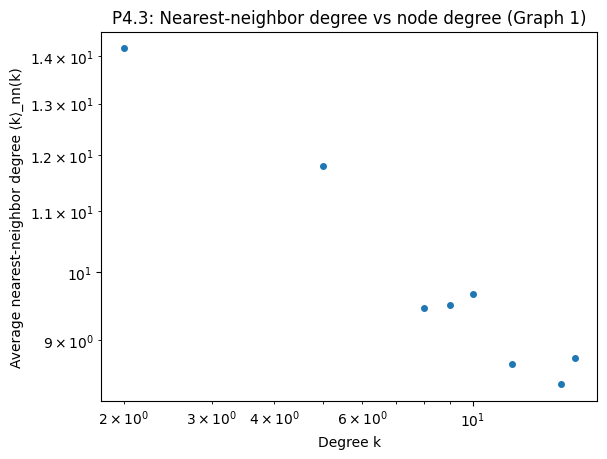

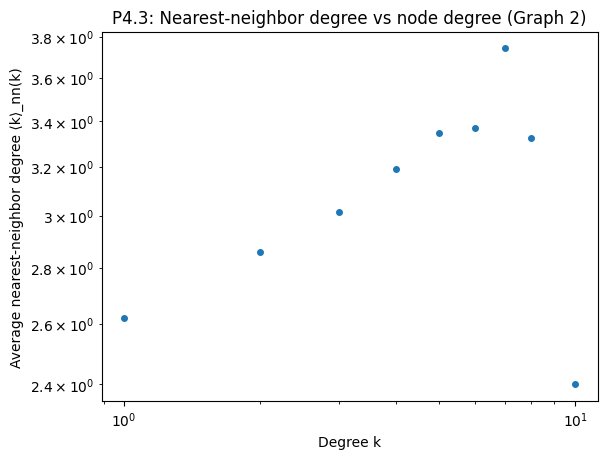

In [11]:
def compute_knn(G):
    deg_dict = dict(G.degree())
    deg_arr = np.array(list(deg_dict.values()))

    knn_node = nx.average_neighbor_degree(G)

    k_values = np.array(sorted(set(deg_arr)))
    k_to_knn = []
    for k in k_values:
        nodes_k = [n for n, d in deg_dict.items() if d == k]
        if len(nodes_k) == 0: 
            continue
        vals = [knn_node[n] for n in nodes_k]
        k_to_knn.append((k, float(np.mean(vals))))

    k_to_knn = np.array(k_to_knn)

    return k_to_knn


for i, G in enumerate(graphs):
    k_to_knn = compute_knn(G)
    plt.figure()
    plt.scatter(k_to_knn[:,0], k_to_knn[:,1], s=16)
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("Degree k")
    plt.ylabel("Average nearest-neighbor degree ⟨k⟩_nn(k)")
    plt.title(f"P4.3: Nearest-neighbor degree vs node degree (Graph {i+1})")
    plt.show()


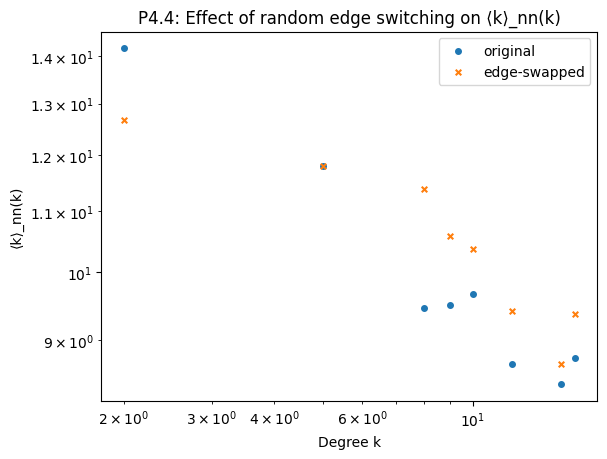

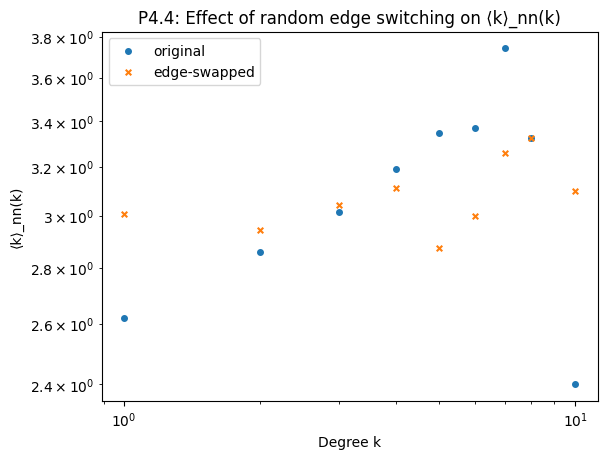

In [12]:
import random
random.seed(42)

def compute_knn_randomized(G):
    G_rand = G.copy()
    nswap = 10 * G_rand.number_of_edges()
    max_tries = 50 * nswap
    nx.double_edge_swap(G_rand, nswap=nswap, max_tries=max_tries)

    deg_rand = dict(G_rand.degree())
    knn_node_rand = nx.average_neighbor_degree(G_rand)

    k_values_rand = np.array(sorted(set(deg_rand.values())))
    k_to_knn_rand = []
    for k in k_values_rand:
        nodes_k = [n for n, d in deg_rand.items() if d == k]
        if len(nodes_k) == 0:
            continue
        vals = [knn_node_rand[n] for n in nodes_k]
        k_to_knn_rand.append((k, float(np.mean(vals))))
    k_to_knn_rand = np.array(k_to_knn_rand)

    return k_to_knn_rand

for i, G in enumerate(graphs):
    k_to_knn = compute_knn(G)
    k_to_knn_rand = compute_knn_randomized(G)

    plt.figure()
    plt.scatter(k_to_knn[:,0], k_to_knn[:,1], s=16, label="original")
    plt.scatter(k_to_knn_rand[:,0], k_to_knn_rand[:,1], s=16, marker='x', label="edge-swapped")
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("Degree k")
    plt.ylabel("⟨k⟩_nn(k)")
    plt.title("P4.4: Effect of random edge switching on ⟨k⟩_nn(k)")
    plt.legend()
    plt.show()


# random switch > lowering correlation slide 7 lecture 4

In [16]:
for G in graphs:
    G_rand = G.copy()
    nswap = 10 * G_rand.number_of_edges()
    max_tries = 50 * nswap
    nx.double_edge_swap(G_rand, nswap=nswap, max_tries=max_tries)

    r_original = nx.degree_assortativity_coefficient(G)
    r_randomized = nx.degree_assortativity_coefficient(G_rand)

    print("P4.6 assortativity r (original):   ", r_original)
    print("P4.6 assortativity r (edge-swapped):", r_randomized)


P4.6 assortativity r (original):    -0.30243295881485316
P4.6 assortativity r (edge-swapped): -0.2719140249759849
P4.6 assortativity r (original):    0.12668357398536234
P4.6 assortativity r (edge-swapped): 0.007055580263930456


In [14]:
import pandas as pd

stats = pd.DataFrame(columns=[
    "Network", "N", "E", "⟨k⟩", "alfa (xmin=2)", "longest path (on LCC)", "r"
])

for G in graphs:
    N = G.number_of_nodes()
    E = G.number_of_edges()
    k_mean = 2*E / N

    deg = np.array([d for _, d in G.degree()], dtype=int)
    xmin = 2
    tail = deg[deg >= xmin]
    alpha_hat = 1 + len(tail) / np.sum(np.log(tail / xmin))

    if nx.is_connected(G):
        LCC = G
    else:
        LCC_nodes = max(nx.connected_components(G), key=len)
        LCC = G.subgraph(LCC_nodes).copy()
    ell = nx.average_shortest_path_length(LCC)

    r = nx.degree_assortativity_coefficient(G)

    print("P4.7 — Euro-road graph metrics")
    print(f"N={N}, E={E}, ⟨k⟩={k_mean:.4f}, α≈{alpha_hat:.4f} (xmin=2, continuous MLE), ℓ≈{ell:.4f}, r≈{r:.4f}")
    new_row = pd.DataFrame([{
        "Network": "Euro-road",
        "N": N, "E": E,
        "⟨k⟩": f"{k_mean:.4f}",
        "alfa (xmin=2)": f"{alpha_hat:.4f}",
        "longest path (on LCC)": f"{ell:.4f}",
        "r": f"{r:.4f}"
    }])
    stats = pd.concat([stats, new_row], ignore_index=True)


P4.7 — Euro-road graph metrics
N=18, E=78, ⟨k⟩=8.6667, α≈1.7628 (xmin=2, continuous MLE), ℓ≈1.6209, r≈-0.3024
P4.7 — Euro-road graph metrics
N=1174, E=1417, ⟨k⟩=2.4140, α≈5.3141 (xmin=2, continuous MLE), ℓ≈18.3951, r≈0.1267


In [15]:
stats
#both undirected graphs

,Network,N,E,⟨k⟩,alfa (xmin=2),longest path (on LCC),r
0,Euro-road,18,78,8.6667,1.7628,1.6209,-0.3024
1,Euro-road,1174,1417,2.4140,5.3141,18.3951,0.1267
